In [1]:
from sklift.datasets import fetch_lenta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier, Pool
import shap

from causalml.metrics import plot_gain, auuc_score
import optuna

from sklearn.metrics import auc
from IPython.display import clear_output

from copy import deepcopy
from sklearn.utils.validation import check_consistent_length
from tqdm import tqdm
from utils import relative_uplift_auc_score, principled_uplift_curve, max_principled_uplift_curve, principled_uplift_auc_score, plot_principled_uplift_curve, sep_qini_auc_score

import warnings
warnings.filterwarnings('ignore')

/Users/kolpakovaksenia/diploma/.dvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
print(sys.executable)

/Users/kolpakovaksenia/diploma/.dvenv/bin/python


In [3]:
SEED = 42

In [4]:
BASE_MODEL = CatBoostClassifier(
    loss_function='Logloss',
    verbose=False,
    random_state=SEED
  )

In [5]:
dataset = fetch_lenta()
data, target, treatment = dataset.data, dataset.target, dataset.treatment

In [6]:
# Преобразование признака gender
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['gender'] = data['gender'].fillna(-1)

In [7]:
# Заполнение пропусков
data = data.fillna(-100)

In [8]:
# Удаление явных дубликатов
data = data.drop_duplicates()

In [9]:
# Разбиение на train, valid, test выборки

data['treatment'] = treatment
data['treatment'] = (data['treatment'] == 'test').astype(int)
data['target'] = target

train_val_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=SEED, stratify=data[['treatment', 'target']])

train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=SEED, stratify=data.loc[train_val_idx, ['treatment', 'target']])

X_train = data.drop(columns=['treatment', 'target']).loc[train_idx]
X_val = data.drop(columns=['treatment', 'target']).loc[val_idx]
X_test = data.drop(columns=['treatment', 'target']).loc[test_idx]

treatment_train = data['treatment'][train_idx]
treatment_val = data['treatment'][val_idx]
treatment_test = data['treatment'][test_idx]

y_train = target[train_idx]
y_val = target[val_idx]
y_test = target[test_idx]

In [10]:
def get_uplift(model_t, model_c, X, treatment, y, selected_features):
    X_selected = X[selected_features]
    
    pred_c = model_c.predict_proba(X_selected)[:, 1]
    pred_t = model_t.predict_proba(X_selected)[:, 1]
    
    uplift_pred = pred_t - pred_c
    
    pred_data = pd.DataFrame({'uplift': uplift_pred,
                            'y': y,
                            'treatment': treatment})
    auuc = auuc_score(pred_data, outcome_col='y', treatment_col='treatment')
    puc = principled_uplift_auc_score(y, uplift_pred, treatment)
  
    print('AUUC:', auuc.squeeze())
    print('PUC:', puc)
    
    return uplift_pred, auuc, puc

In [11]:
def train_tlearner(base_model, X_train, treatment_train, y_train,
                   X_val, treatment_val, y_val,
                   selected_features, n_trials=50):

    X_train = pd.concat([X_train, treatment_train], axis=1)
    y_train = pd.concat([y_train, treatment_train], axis=1)

    base_params = {
        'loss_function': 'Logloss',
        'verbose': False,
        'random_state': SEED
    }

    def objective(trial):

        params_c = {
            'depth': trial.suggest_int('depth_c', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_c', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_c', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_c', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_c', 0, 10),
            'random_strength': trial.suggest_float('random_strength_c', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_c', 1, 100),
        }

        params_t = {
            'depth': trial.suggest_int('depth_t', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_t', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_t', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_t', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_t', 0, 10),
            'random_strength': trial.suggest_float('random_strength_t', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_t', 1, 100),
        }

        X_c = X_train[treatment_train == 0][selected_features]
        y_c = y_train[treatment_train == 0]['response_att']

        X_t = X_train[treatment_train == 1][selected_features]
        y_t = y_train[treatment_train == 1]['response_att']

        model_c = base_model.__class__(**{**params_c, **base_params})
        model_c.fit(X_c, y_c)

        model_t = base_model.__class__(**{**params_t, **base_params})
        model_t.fit(X_t, y_t)

        _, auuc_val, puc = get_uplift(
            model_t,
            model_c,
            X_val,
            treatment_val,
            y_val,
            selected_features
        )

        return auuc_val.item()


    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params

    params_c = {
        'depth': best_params['depth_c'],
        'learning_rate': best_params['learning_rate_c'],
        'iterations': best_params['iterations_c'],
        'l2_leaf_reg': best_params['l2_leaf_reg_c'],
        'bagging_temperature': best_params['bagging_temperature_c'],
        'random_strength': best_params['random_strength_c'],
        'min_data_in_leaf': best_params['min_data_in_leaf_c'],
    }

    params_t = {
        'depth': best_params['depth_t'],
        'learning_rate': best_params['learning_rate_t'],
        'iterations': best_params['iterations_t'],
        'l2_leaf_reg': best_params['l2_leaf_reg_t'],
        'bagging_temperature': best_params['bagging_temperature_t'],
        'random_strength': best_params['random_strength_t'],
        'min_data_in_leaf': best_params['min_data_in_leaf_t'],
    }

    X_c = X_train[treatment_train == 0][selected_features]
    y_c = y_train[treatment_train == 0]['response_att']

    X_t = X_train[treatment_train == 1][selected_features]
    y_t = y_train[treatment_train == 1]['response_att']

    model_c = base_model.__class__(**{**params_c, **base_params})
    model_c.fit(X_c, y_c)

    model_t = base_model.__class__(**{**params_t, **base_params})
    model_t.fit(X_t, y_t)

    uplift_pred_train, auuc_train, puc_train = get_uplift(
        model_t,
        model_c,
        X_train,
        treatment_train,
        y_train['response_att'],
        selected_features
    )

    return model_t, model_c, uplift_pred_train, auuc_train, puc_train, study

Код метрик взяла из оригинального репозитория авторов статьи - в файле utils.py

In [12]:
def check_is_binary(array, name="array"):

    unique = np.unique(array)
    if not np.array_equal(unique, [0, 1]) and not np.array_equal(unique, [0., 1.]):
        raise ValueError(f"{name} must be binary (0/1), got {unique}")

In [13]:
def check_non_constant_features(X, feature_subset):

    if len(feature_subset) == 0:
        return False
    
    X_subset = X[feature_subset]
    
    for col in X_subset.columns:
        if X_subset[col].nunique() > 1:
            return True
    return False


def evaluate_subset(X_train, y_train, treatment_train,
                    X_valid, y_valid, treatment_valid,
                    feature_subset, base_model):

    if len(feature_subset) == 0:
        uplift_pred = np.zeros(len(X_valid))
        puc_score = principled_uplift_auc_score(y_valid, uplift_pred, treatment_valid)
        return puc_score
    
    if not check_non_constant_features(X_train, feature_subset):
        uplift_pred = np.zeros(len(X_valid))
        puc_score = principled_uplift_auc_score(y_valid, uplift_pred, treatment_valid)
        return puc_score
    
    X_train_subset = X_train[feature_subset]
    X_valid_subset = X_valid[feature_subset]
    
    train_trt_mask = treatment_train == 1
    train_ctrl_mask = treatment_train == 0
    
    X_train_trt = X_train_subset[train_trt_mask]
    y_train_trt = y_train[train_trt_mask]
    X_train_ctrl = X_train_subset[train_ctrl_mask]
    y_train_ctrl = y_train[train_ctrl_mask]
    
    if len(X_train_trt) == 0 or len(X_train_ctrl) == 0:
        uplift_pred = np.zeros(len(X_valid))
        puc_score = principled_uplift_auc_score(y_valid, uplift_pred, treatment_valid)
        return puc_score

    if len(X_train_trt) < 2 or len(X_train_ctrl) < 2:
        uplift_pred = np.zeros(len(X_valid))
        puc_score = principled_uplift_auc_score(y_valid, uplift_pred, treatment_valid)
        return puc_score
    
    for col in X_train_subset.columns:
        if X_train_trt[col].std() == 0 or X_train_ctrl[col].std() == 0:
            pass
    
    try:
        model_trt = deepcopy(base_model)
        model_ctrl = deepcopy(base_model)
        
        model_trt.fit(X_train_trt, y_train_trt)
        model_ctrl.fit(X_train_ctrl, y_train_ctrl)
        
        prob_trt = model_trt.predict_proba(X_valid_subset)[:, 1]
        prob_ctrl = model_ctrl.predict_proba(X_valid_subset)[:, 1]
        
        uplift_pred = prob_trt - prob_ctrl
        
        puc_score = principled_uplift_auc_score(y_valid, uplift_pred, treatment_valid)
        
    except Exception as e:
        
        uplift_pred = np.zeros(len(X_valid))
        puc_score = principled_uplift_auc_score(y_valid, uplift_pred, treatment_valid)
    
    return puc_score

def get_puc_importance(X_train, y_train, treatment_train,
                       X_valid, y_valid, treatment_valid,
                       base_model, verbose=True, max_features=None):
    
    feature_scores = {}
    
    features_to_eval = [f for f in X_train.columns if X_train[f].nunique() > 1]
    
    for feat in tqdm(features_to_eval, disable=not verbose):
        puc = evaluate_subset(
            X_train, y_train, treatment_train,
            X_valid, y_valid, treatment_valid,
            [feat], base_model
        )
        feature_scores[feat] = {'puc_score': puc}
    
    const_features = [f for f in X_train.columns if f not in features_to_eval]
    for feat in const_features:
        feature_scores[feat] = {'puc_score': 0.0}
    
    feature_scores_df = pd.DataFrame(feature_scores).T
    feature_scores_df = feature_scores_df.sort_values('puc_score', ascending=False)
    
    return feature_scores_df


In [14]:
feature_scores = get_puc_importance(
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_valid=X_val,
        y_valid=y_val,
        treatment_valid=treatment_val,
        base_model=BASE_MODEL,
        verbose=True,
        max_features=10
    )

100%|█████████████████████████████████████████| 192/192 [33:34<00:00, 10.49s/it]


In [15]:
feature_scores.head(10)

,puc_score
cheque_count_3m_g42,0.068332
cheque_count_3m_g21,0.050599
cheque_count_6m_g42,0.049342
cheque_count_12m_g42,0.045980
cheque_count_3m_g45,0.045075
cheque_count_6m_g41,0.043592
cheque_count_6m_g79,0.042137
k_var_count_per_cheque_1m_g49,0.040408
cheque_count_6m_g56,0.040304
cheque_count_12m_g79,0.040163


In [16]:
selected_features = feature_scores[feature_scores.puc_score > 0].index

In [17]:
len(selected_features)

156

In [19]:
model_t_v1, model_c_v1, uplift_pred_train_v1, auuc_train_v1, puc_train_v1, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features)

[I 2026-04-04 17:55:30,068] A new study created in memory with name: no-name-3817c70c-3546-4f1d-9298-36512bfc8742
[I 2026-04-04 17:58:36,162] Trial 7 finished with value: 0.5147285783441483 and parameters: {'depth_c': 8, 'learning_rate_c': 0.02071760551099907, 'iterations_c': 352, 'l2_leaf_reg_c': 19.481256674180848, 'bagging_temperature_c': 5.162914013248684, 'random_strength_c': 9.979341192330999, 'min_data_in_leaf_c': 25, 'depth_t': 5, 'learning_rate_t': 0.011613114096391932, 'iterations_t': 330, 'l2_leaf_reg_t': 11.259076021318343, 'bagging_temperature_t': 8.365293890169495, 'random_strength_t': 8.289213415595567, 'min_data_in_leaf_t': 89}. Best is trial 7 with value: 0.5147285783441483.


AUUC: 0.5147285783441483
PUC: -0.04210175464363523


[I 2026-04-04 18:01:36,231] Trial 0 finished with value: 0.6168557229570878 and parameters: {'depth_c': 5, 'learning_rate_c': 0.08710885797770858, 'iterations_c': 531, 'l2_leaf_reg_c': 17.20353327702406, 'bagging_temperature_c': 8.80492247489195, 'random_strength_c': 5.791502530899757, 'min_data_in_leaf_c': 53, 'depth_t': 7, 'learning_rate_t': 0.04558119668662103, 'iterations_t': 445, 'l2_leaf_reg_t': 18.520204804838215, 'bagging_temperature_t': 3.371747022670877, 'random_strength_t': 3.472207057886574, 'min_data_in_leaf_t': 50}. Best is trial 0 with value: 0.6168557229570878.


AUUC: 0.6168557229570878
PUC: 0.019753110498873218


[I 2026-04-04 18:01:42,378] Trial 6 finished with value: 0.6091387155736736 and parameters: {'depth_c': 4, 'learning_rate_c': 0.2445157452796004, 'iterations_c': 913, 'l2_leaf_reg_c': 16.792802578967475, 'bagging_temperature_c': 8.536127841570135, 'random_strength_c': 6.916730252257558, 'min_data_in_leaf_c': 68, 'depth_t': 5, 'learning_rate_t': 0.0126093109164459, 'iterations_t': 677, 'l2_leaf_reg_t': 1.3125914923322002, 'bagging_temperature_t': 1.1642247635573177, 'random_strength_t': 8.224581776344165, 'min_data_in_leaf_t': 16}. Best is trial 6 with value: 0.6091387155736736.


...

AUUC: 0.6751517352061182
PUC: 0.014555247793981234


[I 2026-04-04 18:43:58,164] Trial 48 finished with value: 0.7963671788339451 and parameters: {'depth_c': 5, 'learning_rate_c': 0.06896737104066562, 'iterations_c': 1482, 'l2_leaf_reg_c': 11.03591961344762, 'bagging_temperature_c': 6.249397413465603, 'random_strength_c': 6.246506191647287, 'min_data_in_leaf_c': 82, 'depth_t': 8, 'learning_rate_t': 0.014668732249362059, 'iterations_t': 1056, 'l2_leaf_reg_t': 17.995534794997017, 'bagging_temperature_t': 2.432489781336265, 'random_strength_t': 5.8283849309257505, 'min_data_in_leaf_t': 37}. Best is trial 48 with value: 0.7963671788339451.


AUUC: 0.7963671788339451
PUC: 0.014550135899959387


[I 2026-04-04 18:43:59,750] Trial 49 finished with value: 0.6234347524011932 and parameters: {'depth_c': 9, 'learning_rate_c': 0.0749978057124838, 'iterations_c': 466, 'l2_leaf_reg_c': 9.846797662071046, 'bagging_temperature_c': 6.371486600695803, 'random_strength_c': 6.3156656514253715, 'min_data_in_leaf_c': 82, 'depth_t': 8, 'learning_rate_t': 0.014689871911542961, 'iterations_t': 1033, 'l2_leaf_reg_t': 18.020213414076178, 'bagging_temperature_t': 3.691731157598779, 'random_strength_t': 5.9580055157161125, 'min_data_in_leaf_t': 89}. Best is trial 48 with value: 0.7963671788339451.


AUUC: 0.6234347524011932
PUC: 0.02044638924632073
AUUC: 6.313957163970403
PUC: 0.1434177095098542


In [20]:
uplift_pred_test_v1, auuc_test_v1, puc_test_v1 = get_uplift(model_t_v1, model_c_v1, X_test, treatment_test, y_test, selected_features)

AUUC: 0.49196924903147365
PUC: 0.0008394491955783989


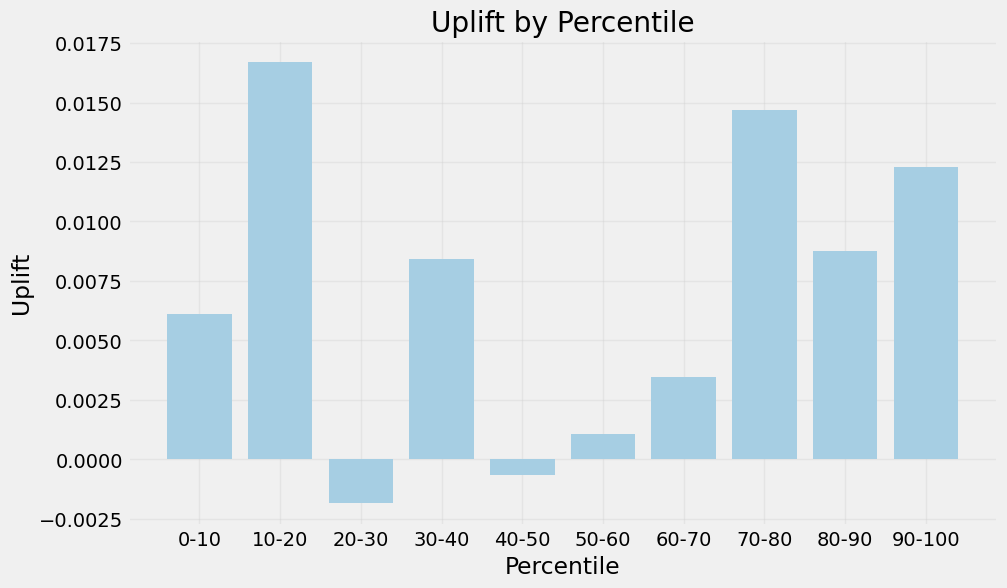

In [21]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v1, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

Попробуем обучить модель на ТОП-50 фичах:

In [22]:
selected_features_v2 = selected_features[:50]

In [23]:
model_t_v2, model_c_v2, uplift_pred_train_v2, auuc_train_v2, puc_train_v2, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_v2)

[I 2026-04-04 18:44:41,911] A new study created in memory with name: no-name-12db5c29-1b2e-4505-8734-7da0fc594f03
[I 2026-04-04 18:46:39,939] Trial 10 finished with value: 0.4958103062194887 and parameters: {'depth_c': 7, 'learning_rate_c': 0.1955387112749438, 'iterations_c': 389, 'l2_leaf_reg_c': 1.5535111554013792, 'bagging_temperature_c': 1.1578482780931687, 'random_strength_c': 3.322555583689687, 'min_data_in_leaf_c': 6, 'depth_t': 6, 'learning_rate_t': 0.03988457457158957, 'iterations_t': 724, 'l2_leaf_reg_t': 19.43269283295667, 'bagging_temperature_t': 7.436064611081447, 'random_strength_t': 4.338265693920091, 'min_data_in_leaf_t': 5}. Best is trial 10 with value: 0.4958103062194887.


AUUC: 0.4958103062194887
PUC: 0.01569338349614508


[I 2026-04-04 18:46:45,208] Trial 5 finished with value: 0.5142831944102897 and parameters: {'depth_c': 8, 'learning_rate_c': 0.028878489487422748, 'iterations_c': 303, 'l2_leaf_reg_c': 3.196167822444715, 'bagging_temperature_c': 5.904621875055918, 'random_strength_c': 1.695175474106413, 'min_data_in_leaf_c': 96, 'depth_t': 7, 'learning_rate_t': 0.24929447516900907, 'iterations_t': 701, 'l2_leaf_reg_t': 17.939463806022893, 'bagging_temperature_t': 8.072197053552761, 'random_strength_t': 0.011481522861765958, 'min_data_in_leaf_t': 94}. Best is trial 5 with value: 0.5142831944102897.


AUUC: 0.5142831944102897
PUC: 0.021341362407563114


[I 2026-04-04 18:46:52,975] Trial 4 finished with value: 0.6831928621410761 and parameters: {'depth_c': 8, 'learning_rate_c': 0.08263563609301502, 'iterations_c': 936, 'l2_leaf_reg_c': 6.51268882351327, 'bagging_temperature_c': 6.8740767551675495, 'random_strength_c': 8.58128325583679, 'min_data_in_leaf_c': 2, 'depth_t': 8, 'learning_rate_t': 0.20954024226116105, 'iterations_t': 392, 'l2_leaf_reg_t': 11.974683869194628, 'bagging_temperature_t': 7.317177976090941, 'random_strength_t': 5.731808227540349, 'min_data_in_leaf_t': 30}. Best is trial 4 with value: 0.6831928621410761.


...

AUUC: 0.4689951692943065
PUC: 0.01714489435910962
AUUC: 0.4874018959282474
PUC: 0.00037468996339070547


[I 2026-04-04 19:00:21,775] Trial 48 finished with value: 0.44514335057119103 and parameters: {'depth_c': 5, 'learning_rate_c': 0.02629524171318119, 'iterations_c': 1076, 'l2_leaf_reg_c': 9.553345410232517, 'bagging_temperature_c': 1.9980379929466356, 'random_strength_c': 9.913749054901617, 'min_data_in_leaf_c': 26, 'depth_t': 9, 'learning_rate_t': 0.22206972516069315, 'iterations_t': 1054, 'l2_leaf_reg_t': 6.947254047504794, 'bagging_temperature_t': 0.02361898332113732, 'random_strength_t': 4.650110623809115, 'min_data_in_leaf_t': 4}. Best is trial 22 with value: 0.6859545307080724.


AUUC: 0.44514335057119103
PUC: -0.006713968140906168


[I 2026-04-04 19:00:23,266] Trial 49 finished with value: 0.6860271587944935 and parameters: {'depth_c': 4, 'learning_rate_c': 0.026954504948415184, 'iterations_c': 1106, 'l2_leaf_reg_c': 13.864287741938732, 'bagging_temperature_c': 7.482920585020947, 'random_strength_c': 9.88120376385738, 'min_data_in_leaf_c': 41, 'depth_t': 9, 'learning_rate_t': 0.022608599817302146, 'iterations_t': 1002, 'l2_leaf_reg_t': 7.1412022705277725, 'bagging_temperature_t': 7.645431880037284, 'random_strength_t': 4.588758062648056, 'min_data_in_leaf_t': 2}. Best is trial 49 with value: 0.6860271587944935.


AUUC: 0.6860271587944935
PUC: 0.03971230846884161
AUUC: 4.475090651248165
PUC: 0.20525929128214138


In [24]:
uplift_pred_test_v2, auuc_test_v2, puc_test_v2 = get_uplift(model_t_v2, model_c_v2, X_test, treatment_test, y_test, selected_features_v2)

AUUC: 0.6179562975362791
PUC: 0.03569255806314356


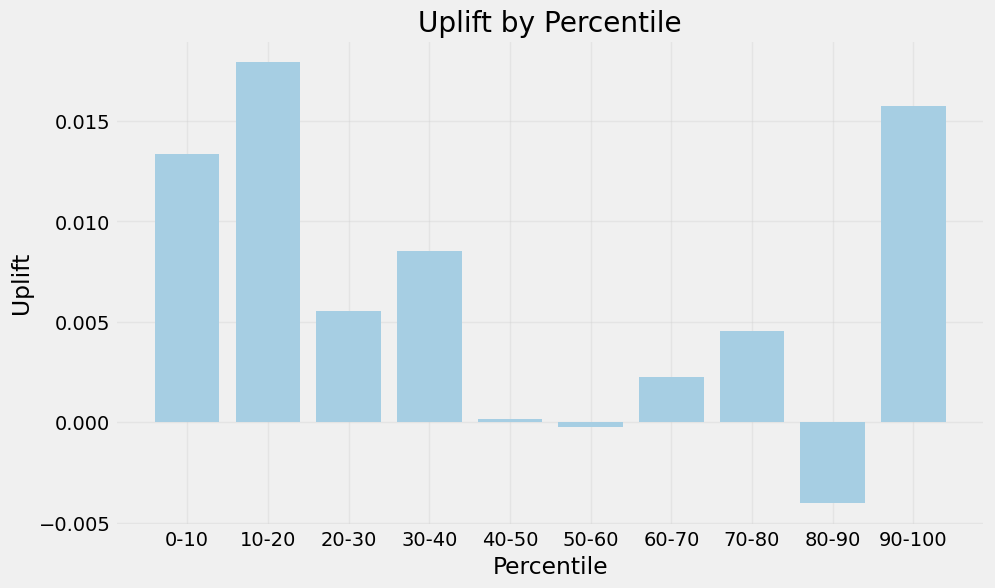

In [25]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v2, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

Если проводить оптимизацию по puc:

In [26]:
def train_tlearner_puc_opt(base_model, X_train, treatment_train, y_train,
                   X_val, treatment_val, y_val,
                   selected_features, n_trials=50):

    X_train = pd.concat([X_train, treatment_train], axis=1)
    y_train = pd.concat([y_train, treatment_train], axis=1)

    base_params = {
        'loss_function': 'Logloss',
        'verbose': False,
        'random_state': SEED
    }

    def objective(trial):

        params_c = {
            'depth': trial.suggest_int('depth_c', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_c', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_c', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_c', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_c', 0, 10),
            'random_strength': trial.suggest_float('random_strength_c', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_c', 1, 100),
        }

        params_t = {
            'depth': trial.suggest_int('depth_t', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_t', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_t', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_t', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_t', 0, 10),
            'random_strength': trial.suggest_float('random_strength_t', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_t', 1, 100),
        }

        X_c = X_train[treatment_train == 0][selected_features]
        y_c = y_train[treatment_train == 0]['response_att']

        X_t = X_train[treatment_train == 1][selected_features]
        y_t = y_train[treatment_train == 1]['response_att']

        model_c = base_model.__class__(**{**params_c, **base_params})
        model_c.fit(X_c, y_c)

        model_t = base_model.__class__(**{**params_t, **base_params})
        model_t.fit(X_t, y_t)

        _, auuc_val, puc = get_uplift(
            model_t,
            model_c,
            X_val,
            treatment_val,
            y_val,
            selected_features
        )

        return puc


    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params

    params_c = {
        'depth': best_params['depth_c'],
        'learning_rate': best_params['learning_rate_c'],
        'iterations': best_params['iterations_c'],
        'l2_leaf_reg': best_params['l2_leaf_reg_c'],
        'bagging_temperature': best_params['bagging_temperature_c'],
        'random_strength': best_params['random_strength_c'],
        'min_data_in_leaf': best_params['min_data_in_leaf_c'],
    }

    params_t = {
        'depth': best_params['depth_t'],
        'learning_rate': best_params['learning_rate_t'],
        'iterations': best_params['iterations_t'],
        'l2_leaf_reg': best_params['l2_leaf_reg_t'],
        'bagging_temperature': best_params['bagging_temperature_t'],
        'random_strength': best_params['random_strength_t'],
        'min_data_in_leaf': best_params['min_data_in_leaf_t'],
    }

    X_c = X_train[treatment_train == 0][selected_features]
    y_c = y_train[treatment_train == 0]['response_att']

    X_t = X_train[treatment_train == 1][selected_features]
    y_t = y_train[treatment_train == 1]['response_att']

    model_c = base_model.__class__(**{**params_c, **base_params})
    model_c.fit(X_c, y_c)

    model_t = base_model.__class__(**{**params_t, **base_params})
    model_t.fit(X_t, y_t)

    uplift_pred_train, auuc_train, puc_train = get_uplift(
        model_t,
        model_c,
        X_train,
        treatment_train,
        y_train['response_att'],
        selected_features
    )

    return model_t, model_c, uplift_pred_train, auuc_train, puc_train, study

In [27]:
model_t_v3, model_c_v3, uplift_pred_train_v3, auuc_train_v3, puc_train_v3, study = train_tlearner_puc_opt(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features)

[I 2026-04-04 19:00:48,184] A new study created in memory with name: no-name-cbee5b9f-c422-4b4b-943e-99b589c67e94
[I 2026-04-04 19:03:38,480] Trial 7 finished with value: 0.02239020577302304 and parameters: {'depth_c': 7, 'learning_rate_c': 0.022324169031270553, 'iterations_c': 371, 'l2_leaf_reg_c': 17.83296366945001, 'bagging_temperature_c': 8.210777282181132, 'random_strength_c': 9.913453709751568, 'min_data_in_leaf_c': 89, 'depth_t': 6, 'learning_rate_t': 0.014722520578605765, 'iterations_t': 457, 'l2_leaf_reg_t': 9.819809193748434, 'bagging_temperature_t': 9.978998132949188, 'random_strength_t': 9.467665897905885, 'min_data_in_leaf_t': 21}. Best is trial 7 with value: 0.02239020577302304.


AUUC: 0.5761036838364824
PUC: 0.02239020577302304


[I 2026-04-04 19:03:55,720] Trial 9 finished with value: 0.025936230811081953 and parameters: {'depth_c': 4, 'learning_rate_c': 0.03408434200725306, 'iterations_c': 846, 'l2_leaf_reg_c': 11.493583201696554, 'bagging_temperature_c': 5.359179641710858, 'random_strength_c': 0.26873370169271493, 'min_data_in_leaf_c': 14, 'depth_t': 6, 'learning_rate_t': 0.16648827912899727, 'iterations_t': 476, 'l2_leaf_reg_t': 19.451944759053493, 'bagging_temperature_t': 8.638577541925534, 'random_strength_t': 6.149572323982269, 'min_data_in_leaf_t': 74}. Best is trial 9 with value: 0.025936230811081953.


AUUC: 0.5212962076098602
PUC: 0.025936230811081953


[I 2026-04-04 19:05:43,421] Trial 1 finished with value: 0.022380376435098485 and parameters: {'depth_c': 7, 'learning_rate_c': 0.015158252872865005, 'iterations_c': 1186, 'l2_leaf_reg_c': 4.720145673725934, 'bagging_temperature_c': 9.928864063934991, 'random_strength_c': 2.69338041463983, 'min_data_in_leaf_c': 73, 'depth_t': 6, 'learning_rate_t': 0.2701602148780491, 'iterations_t': 517, 'l2_leaf_reg_t': 14.717717476902912, 'bagging_temperature_t': 7.652742277438467, 'random_strength_t': 0.1311552294382945, 'min_data_in_leaf_t': 52}. Best is trial 9 with value: 0.025936230811081953.


...

AUUC: 0.7191476678616544
PUC: 0.032368143429850595


[I 2026-04-04 19:50:05,568] Trial 36 finished with value: 0.0472748482746744 and parameters: {'depth_c': 9, 'learning_rate_c': 0.29051358185004744, 'iterations_c': 593, 'l2_leaf_reg_c': 1.775630776839169, 'bagging_temperature_c': 0.7519748608447863, 'random_strength_c': 3.546576793295176, 'min_data_in_leaf_c': 35, 'depth_t': 10, 'learning_rate_t': 0.039468893904657625, 'iterations_t': 1260, 'l2_leaf_reg_t': 14.12566005702156, 'bagging_temperature_t': 5.9224724404627995, 'random_strength_t': 5.4250129822862, 'min_data_in_leaf_t': 34}. Best is trial 41 with value: 0.05511125489795906.


AUUC: 0.6265112209326397
PUC: 0.0472748482746744


[I 2026-04-04 19:50:14,758] Trial 49 finished with value: 0.038498708125743214 and parameters: {'depth_c': 9, 'learning_rate_c': 0.013023461425906007, 'iterations_c': 991, 'l2_leaf_reg_c': 19.835485988763118, 'bagging_temperature_c': 4.604955939776091, 'random_strength_c': 1.3748174039407104, 'min_data_in_leaf_c': 65, 'depth_t': 9, 'learning_rate_t': 0.016740614100815746, 'iterations_t': 980, 'l2_leaf_reg_t': 10.474191066018108, 'bagging_temperature_t': 4.065900380654409, 'random_strength_t': 0.17134350047190328, 'min_data_in_leaf_t': 12}. Best is trial 41 with value: 0.05511125489795906.


AUUC: 0.5597092015365207
PUC: 0.038498708125743214
AUUC: 5.09424475545006
PUC: 0.27339871668176474


In [28]:
uplift_pred_test_v3, auuc_test_v3, puc_test_v3 = get_uplift(model_t_v3, model_c_v3, X_test, treatment_test, y_test, selected_features)

AUUC: 0.7060219789574962
PUC: 0.05867838925080081


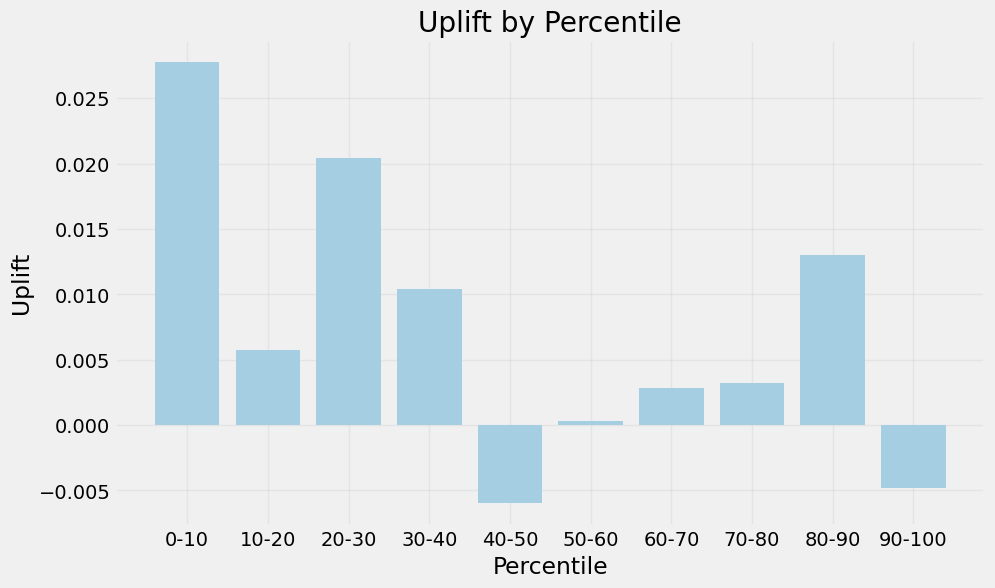

In [29]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v3, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
model_t_v4, model_c_v4, uplift_pred_train_v4, auuc_train_v4, puc_train_v4, study = train_tlearner_puc_opt(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, selected_features_v2)

[I 2026-04-04 19:51:01,244] A new study created in memory with name: no-name-273a7aa7-dd15-4411-8ba2-b273936bebfc
[I 2026-04-04 19:52:45,811] Trial 4 finished with value: -0.015518589234059068 and parameters: {'depth_c': 7, 'learning_rate_c': 0.09166967176729161, 'iterations_c': 876, 'l2_leaf_reg_c': 15.875870578219292, 'bagging_temperature_c': 7.228467728786505, 'random_strength_c': 0.6874794111226035, 'min_data_in_leaf_c': 17, 'depth_t': 7, 'learning_rate_t': 0.01043014773858398, 'iterations_t': 393, 'l2_leaf_reg_t': 17.219797410083387, 'bagging_temperature_t': 0.825098587041837, 'random_strength_t': 3.2106859080603414, 'min_data_in_leaf_t': 71}. Best is trial 4 with value: -0.015518589234059068.


AUUC: 0.5401173211851831
PUC: -0.015518589234059068


[I 2026-04-04 19:53:39,375] Trial 6 finished with value: 0.049003015530269645 and parameters: {'depth_c': 8, 'learning_rate_c': 0.014246545284448709, 'iterations_c': 693, 'l2_leaf_reg_c': 15.210902074998296, 'bagging_temperature_c': 4.379951851128149, 'random_strength_c': 6.292943850726363, 'min_data_in_leaf_c': 11, 'depth_t': 7, 'learning_rate_t': 0.038722296125546306, 'iterations_t': 778, 'l2_leaf_reg_t': 18.077182098851825, 'bagging_temperature_t': 5.63928991795291, 'random_strength_t': 3.207079324133746, 'min_data_in_leaf_t': 58}. Best is trial 6 with value: 0.049003015530269645.


AUUC: 0.6148898774843625
PUC: 0.049003015530269645


[I 2026-04-04 19:53:50,805] Trial 7 finished with value: -0.0008060124418952597 and parameters: {'depth_c': 5, 'learning_rate_c': 0.20631227990137305, 'iterations_c': 1074, 'l2_leaf_reg_c': 11.850426766229477, 'bagging_temperature_c': 3.761187936028769, 'random_strength_c': 7.6550882548570085, 'min_data_in_leaf_c': 86, 'depth_t': 10, 'learning_rate_t': 0.02288502124579019, 'iterations_t': 319, 'l2_leaf_reg_t': 13.317354998075732, 'bagging_temperature_t': 6.007126446294471, 'random_strength_t': 4.850352171066703, 'min_data_in_leaf_t': 96}. Best is trial 6 with value: 0.049003015530269645.


...

AUUC: 0.5664264039695996
PUC: 0.05102884452001692


[I 2026-04-04 20:01:21,762] Trial 45 finished with value: 0.04425881634027601 and parameters: {'depth_c': 4, 'learning_rate_c': 0.018536983276848138, 'iterations_c': 340, 'l2_leaf_reg_c': 10.170817271458489, 'bagging_temperature_c': 2.233135074337145, 'random_strength_c': 3.89673566215048, 'min_data_in_leaf_c': 54, 'depth_t': 8, 'learning_rate_t': 0.07714827768547217, 'iterations_t': 1000, 'l2_leaf_reg_t': 5.397224241510116, 'bagging_temperature_t': 8.37355921279986, 'random_strength_t': 9.837860969978653, 'min_data_in_leaf_t': 88}. Best is trial 28 with value: 0.06243651724893993.


AUUC: 0.5323820207226855
PUC: 0.04425881634027601


[I 2026-04-04 20:01:22,311] Trial 46 finished with value: 0.04123518014561625 and parameters: {'depth_c': 4, 'learning_rate_c': 0.019157989551372042, 'iterations_c': 324, 'l2_leaf_reg_c': 6.072168578310521, 'bagging_temperature_c': 2.1054482525005556, 'random_strength_c': 3.7083085350339626, 'min_data_in_leaf_c': 5, 'depth_t': 8, 'learning_rate_t': 0.09077719762122922, 'iterations_t': 1035, 'l2_leaf_reg_t': 5.1241637377739, 'bagging_temperature_t': 8.186871207153734, 'random_strength_t': 7.240655337627466, 'min_data_in_leaf_t': 87}. Best is trial 28 with value: 0.06243651724893993.


AUUC: 0.6328568710786381
PUC: 0.04123518014561625
AUUC: 1.2370537643453337
PUC: 0.095720707660637


In [31]:
uplift_pred_test_v4, auuc_test_v4, puc_test_v4 = get_uplift(model_t_v4, model_c_v4, X_test, treatment_test, y_test, selected_features_v2)

AUUC: 0.629670227726666
PUC: 0.06364334486853256


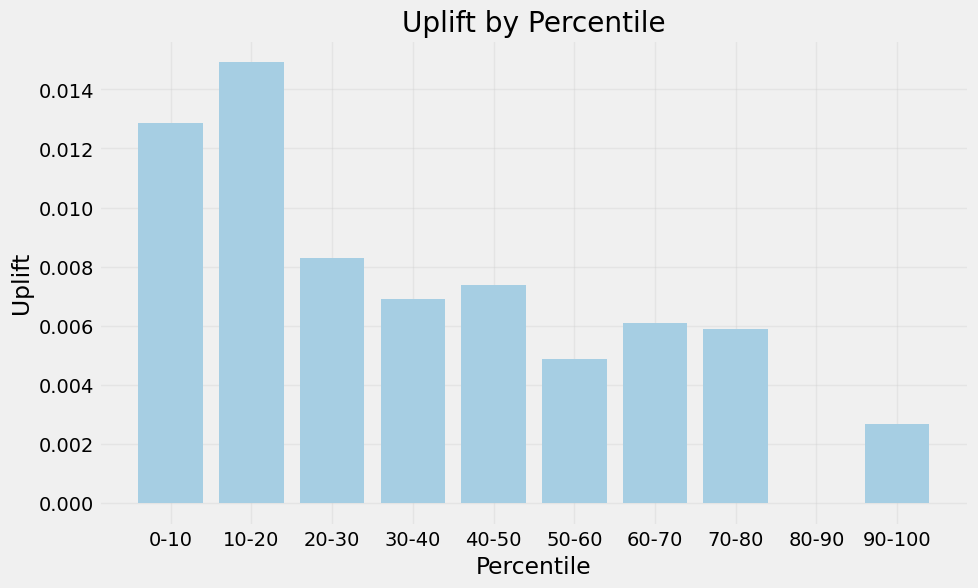

In [32]:
import matplotlib.pyplot as plt
from sklift.metrics import uplift_by_percentile

result = uplift_by_percentile(
    y_test, uplift_pred_test_v4, treatment_test, 
    strategy='overall', bins=10
)

# Строим график
plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()